### concat()
- 데이터를 데이터 형식과 관계없이 연결하는 방식
- concat([df1, df2])

In [1]:
import pandas as pd

In [2]:
df1 = pd.DataFrame({'A':['A0','A1','A2','A3'],
                    'B':['B0','B1','B2','B3'],
                    'C':['C0','C1','C2','C3']
                   }, index = [0,1,2,3])

df2 = pd.DataFrame({'A':['A4','A5','A6','A7'],
                    'B':['B4','B5','B6','B7'],
                    'C':['C4','C5','C6','C7']},
                  index= [4,5,6,7])

df3 = pd.DataFrame({'A':['A8','A9','A10','A11'],
                    'B':['B8','B9','B10','B11'],
                    'C':['C8','C9','C10','C11']},
                  index= [8,9,10,11])

In [4]:
pd.concat([df1, df2, df3])

,A,B,C
0,A0,B0,C0
1,A1,B1,C1
2,A2,B2,C2
3,A3,B3,C3
4,A4,B4,C4
5,A5,B5,C5
6,A6,B6,C6
7,A7,B7,C7
8,A8,B8,C8
9,A9,B9,C9


In [3]:
df4 = pd.DataFrame({'B':['B2','B3','B6','B7'],
                    'D':['D2','D3','D6','D7'],
                    'F':['F2','F3','F6','F7']
                   }, index = [2,3,6,7])
df4

,B,D,F
2,B2,D2,F2
3,B3,D3,F3
6,B6,D6,F6
7,B7,D7,F7


In [7]:
# df1 과 df4 를 열로 가져다 붙여서 인덱스 번호가 같은것끼리 병합
pd.concat([df1, df4],axis=1)

,A,B,C,B,D,F
0,A0,B0,C0,NaN,NaN,NaN
1,A1,B1,C1,NaN,NaN,NaN
2,A2,B2,C2,B2,D2,F2
3,A3,B3,C3,B3,D3,F3
6,NaN,NaN,NaN,B6,D6,F6
7,NaN,NaN,NaN,B7,D7,F7


In [40]:
#결측치 없이 존재하는 것들끼리 병합하고싶다면
pd.concat([df1,df4],axis=1,join="inner")

,A,B,C,B,D,F
2,A2,B2,C2,B2,D2,F2
3,A3,B3,C3,B3,D3,F3


### merge
- 데이터프레임을 병합하는 함수
- merge(df1, df2)


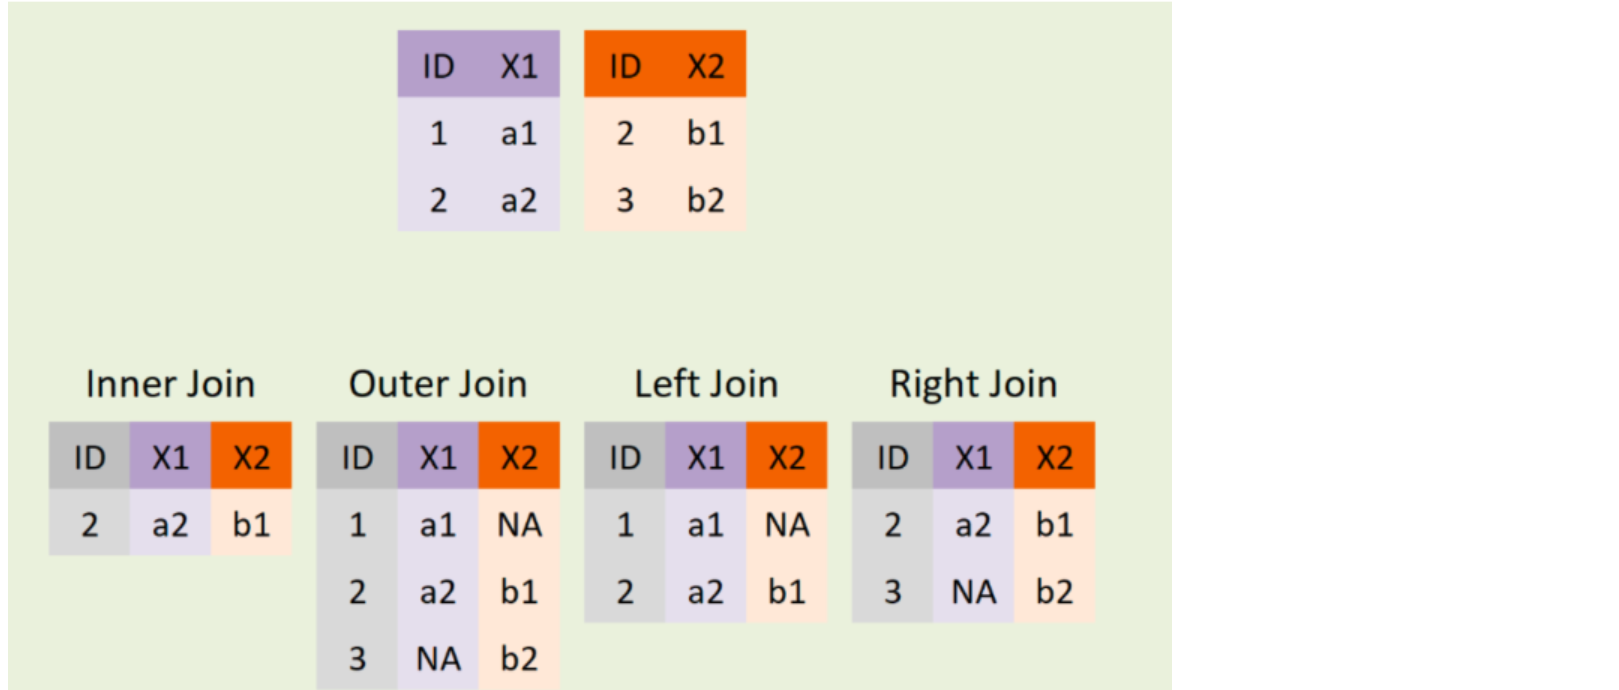

In [41]:
df5 = pd.DataFrame({'key':['K0','K1','K2','K3'],
                    'A':['A0','A1','A2','A3'],
                    'B':['B0','B1','B2','B3']})

df6 = pd.DataFrame({'key':['K0','K2','K3','K4'],
                    'C':['C0','C1','C2','C3'],
                    'D':['D0','D1','D2','D3']})

In [44]:
pd.merge(df5, df6, on="key",how="inner")

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K2,A2,B2,C1,D1
2,K3,A3,B3,C2,D2


In [45]:
pd.merge(df5,df6,on="key",how="outer")

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,NaN,NaN
2,K2,A2,B2,C1,D1
3,K3,A3,B3,C2,D2
4,K4,NaN,NaN,C3,D3


In [ ]:
#how -> left: 병합하고싶은 데이터프레임 중 왼쪽에 있는 데이터프레임이 메인이 된다.
pd.merge(df5,df6,on="key",how="left")


,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,NaN,NaN
2,K2,A2,B2,C1,D1
3,K3,A3,B3,C2,D2


In [ ]:
#how -> right : 병합하고싶은 데이터프레임 중 오른쪽에 있는 데이터프레임이 메인
pd.merge(df5,df6,on="key",how="right")

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K2,A2,B2,C1,D1
2,K3,A3,B3,C2,D2
3,K4,NaN,NaN,C3,D3


### concat과 merge의 차이점
- concat
    - 병합기준 : 인덱스명, 컬럼명
    - 단순연결(행,열 중시)
- merge
    - 병합기준 : 공통된 컬럼값
    - 데이터간의 관계를 바탕으로 결합
    - join 방식 : inner, left, outer, right